# 39. Krylov Methods for Eigenvalues

**Part 6: Eigenvalue Problems and the Singular Value Decomposition**

## Learning objectives

By the end of this lesson you will be able to:

1. Say why lessons 37 and 38 stop working, and what replaces them.
2. State the **Rayleigh-Ritz** procedure and recognise it as lesson 36's Rayleigh quotient with
   a subspace in place of a vector.
3. Use the **free** residual $|h_{m+1,m}||s_m|$ as a rigorous stopping test without forming a
   Ritz vector.
4. Predict **which** eigenvalues converge first, and measure it with a metric that cannot be
   fooled by an accident.
5. Recognise **ghost eigenvalues**, explain them by Paige's theorem, and say why they are a
   symptom of success.
6. Use **restarting** to keep the basis bounded, and say what it costs.
7. Solve an eigenvalue problem on a matrix that would take **8000 GB** to store.
8. Recognise when a Krylov method is the wrong tool, and say so from the spectrum.

## Prerequisites

Lesson 26 (Krylov spaces, Arnoldi, Lanczos, loss of orthogonality). Lesson 36 (the Rayleigh
quotient and its optimality). Lesson 24 (the Chebyshev bound, which reappears here as
Kaniel-Paige). Lesson 30 (twice is enough, used for the reorthogonalization).

---

## 1. When reduction is not available

Lessons 37 and 38 both begin by reducing $A$: to Hessenberg, then to tridiagonal. **Both cost
$O(n^3)$ and both need $A$ in memory.**

At $n = 10^6$ a dense matrix is 8000 GB and $n^3$ is $10^{18}$ operations. And many matrices
never exist as arrays at all: a discretised operator, a Jacobian accessed by directional
differences (lesson 14), a convolution applied by FFT. **All of them can multiply a vector, and
none of them can be reduced.**

**Krylov methods need only that one operation.** Lesson 26 built the space

$$K_m(A,\mathbf{v}) = \operatorname{span}(\mathbf{v}, A\mathbf{v},\dots,A^{m-1}\mathbf{v})$$

and the Arnoldi and Lanczos recurrences that orthonormalise it. This lesson reads eigenvalues
off it.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import krylov_eig as ke

for n in (1000, 10_000, 1_000_000):
    op = ke.sparse_laplacian(n)
    dense_gb = n * n * 8 / 1e9
    print(f"n = {n:>9}: a dense matrix would be {dense_gb:>10.1f} GB, "
          f"and one matvec costs {op.shape[0]} flops")
big = ke.sparse_laplacian(1_000_000)
x = np.ones(1_000_000)
y = big.matvec(x)
print(f"\napplying the million by million operator: result of length {y.size}, "
      f"y[0] = {y[0]:.1f}, y[500000] = {y[500000]:.1f}")

n =      1000: a dense matrix would be        0.0 GB, and one matvec costs 1000 flops
n =     10000: a dense matrix would be        0.8 GB, and one matvec costs 10000 flops
n =   1000000: a dense matrix would be     8000.0 GB, and one matvec costs 1000000 flops

applying the million by million operator: result of length 1000000, y[0] = 1.0, y[500000] = 0.0


---

## 2. Rayleigh-Ritz

Given an orthonormal basis $Q$ of a subspace $S$, project:

$$H = Q^TAQ, \qquad H\mathbf{s} = \theta\mathbf{s}
\ \Longrightarrow\ (\theta,\ Q\mathbf{s}) \text{ is a } \textbf{Ritz pair}.$$

**This is lesson 36's Rayleigh quotient with a subspace in place of a vector**, and it has the
same optimality: the residual $A\mathbf{y}-\theta\mathbf{y}$ is **orthogonal to $S$**, so no
better approximation is available from $S$.

In [3]:
size, sub = 40, 12
A_rr = rng.standard_normal((size, size))
A_rr = A_rr + A_rr.T
Q_rr, _ = np.linalg.qr(rng.standard_normal((size, sub)))
out_rr = ke.rayleigh_ritz(A_rr, Q_rr)

worst = max(np.linalg.norm(Q_rr.T @ (A_rr @ out_rr["vectors"][:, j]
                                     - out_rr["values"][j] * out_rr["vectors"][:, j]))
            for j in range(sub))
print(f"the residual is orthogonal to the subspace to {worst:.2e}")

exact_rr = np.sort(np.linalg.eigvalsh(A_rr))
theta_rr = np.sort(out_rr["values"])
print(f"\nthe true spectrum spans [{exact_rr[0]:.4f}, {exact_rr[-1]:.4f}]")
print(f"the {sub} Ritz values span [{theta_rr[0]:.4f}, {theta_rr[-1]:.4f}]")
print("\nThe Ritz values lie INSIDE the true spectrum, always. They approach the")
print("extremes from within and can never overshoot.")
assert theta_rr[0] >= exact_rr[0] - 1e-10 and theta_rr[-1] <= exact_rr[-1] + 1e-10

the residual is orthogonal to the subspace to 1.15e-14

the true spectrum spans [-16.3548, 14.7498]
the 12 Ritz values span [-9.0181, 8.3134]

The Ritz values lie INSIDE the true spectrum, always. They approach the
extremes from within and can never overshoot.


---

## 3. The stopping test is free

The Arnoldi relation is

$$AQ_m = Q_mH_m + h_{m+1,m}\mathbf{q}_{m+1}\mathbf{e}_m^T.$$

Multiply by the small eigenvector $\mathbf{s}$, using $H_m\mathbf{s} = \theta\mathbf{s}$:

$$A(Q_m\mathbf{s}) - \theta(Q_m\mathbf{s}) = h_{m+1,m}\,(\mathbf{e}_m^T\mathbf{s})\,\mathbf{q}_{m+1}.$$

$\mathbf{q}_{m+1}$ is a unit vector, so

$$\|A\mathbf{y} - \theta\mathbf{y}\| = |h_{m+1,m}|\,|s_m|$$

**exactly**: one number already computed, times the last entry of a small eigenvector. **No
Ritz vector need be formed and no matrix-vector product is needed.**

In [4]:
op_r = ke.sparse_laplacian(100)
out_r = ke.lanczos_eigen(op_r, m=25, rng=np.random.default_rng(2))

print(f"{'Ritz':>6}{'theta':>12}{'free bound':>14}{'true residual':>16}{'ratio':>9}")
for j in (0, 1, 6, 12, 23, 24):
    y = out_r.vectors[:, j]
    true = float(np.linalg.norm(op_r.matvec(y) - out_r.values[j] * y))
    print(f"{j:>6}{out_r.values[j]:>12.6f}{out_r.residuals[j]:>14.4e}"
          f"{true:>16.4e}{true / max(out_r.residuals[j], 1e-300):>9.4f}")
    assert abs(true - out_r.residuals[j]) < 1e-9 * max(true, 1e-12)

  Ritz       theta    free bound   true residual    ratio
     0    3.991008    1.3348e-02      1.3348e-02   1.0000
     1    3.963177    3.4053e-02      3.4053e-02   1.0000
     6    3.399569    1.1180e-01      1.1180e-01   1.0000
    12    1.986756    2.5280e-01      2.5280e-01   1.0000
    23    0.051905    5.4063e-02      5.4063e-02   1.0000
    24    0.006589    1.8699e-02      1.8699e-02   1.0000


**Ratio 1.0000 everywhere.** And for a symmetric $A$ the residual bounds the eigenvalue error
directly: some true eigenvalue is within $|h_{m+1,m}||s_m|$ of $\theta$. That is lesson 35's
Bauer-Fike with $\kappa(V) = 1$.

---

## 4. Which converge first, and how to measure it

**The extremes go first.** Kaniel and Paige's bound has the error in the outermost Ritz value
decaying like $1/T_{m-1}(1+2\gamma)^2$, with $\gamma$ the relative gap and $T$ the Chebyshev
polynomial: **the same expression that governed the conjugate gradient method in lesson 24**,
for the same reason. Interior eigenvalues have no such bound.

**The obvious way to measure this is wrong**, and it is worth seeing why before trusting a
number. Taking one interior eigenvalue and asking how close the *nearest* Ritz value is rewards
accidents: with a handful of Ritz values spread across the spectrum, one lands near the middle
by chance.

In [5]:
op_c = ke.sparse_laplacian(200)
exact_c = ke.laplacian_eigenvalues(200)

print("distance from EVERY true eigenvalue to its nearest Ritz value,")
print("summarised as medians over bands of the spectrum\n")
print(f"{'m':>5}{'outer 15%':>13}{'inner 30%':>13}{'interior is worse by':>23}")
for m in (10, 20, 40, 80):
    c = ke.convergence_order(op_c, m, exact=exact_c, rng=np.random.default_rng(3))
    d, p = c["distance"], c["position"]
    outer = float(np.median(d[(p < 0.15) | (p > 0.85)]))
    inner = float(np.median(d[(p > 0.35) & (p < 0.65)]))
    print(f"{m:>5}{outer:>13.2e}{inner:>13.2e}{inner / outer:>22.1f}x")
    assert inner > 2.0 * outer

distance from EVERY true eigenvalue to its nearest Ritz value,
summarised as medians over bands of the spectrum

    m    outer 15%    inner 30%   interior is worse by
   10     2.59e-02     1.57e-01                   6.0x
   20     1.39e-02     7.48e-02                   5.4x
   40     6.81e-03     3.76e-02                   5.5x
   80     4.21e-03     1.82e-02                   4.3x


**The interior is 4 to 6 times worse at every basis size**, and consistently so, which a single
eigenvalue's distance could not have shown.

**The practical consequence.** Krylov eigenvalue methods are for the **ends** of a spectrum. If
you want an interior eigenvalue, apply the method to $(A-\sigma I)^{-1}$ instead, which is
lesson 36's shift-and-invert with a subspace: it turns the interior eigenvalue nearest $\sigma$
into an extreme one. The price is a factorization, which is exactly what Krylov methods exist to
avoid, so the trade has to be worth it.

---

## 5. Ghosts

Lesson 26 measured Lanczos losing orthogonality on a linear solve. Here the symptom is
different and more alarming: **converged eigenvalues appear twice**.

**Paige's theorem says why, and the explanation is the opposite of what it looks like.**
Orthogonality is lost **exactly when a Ritz value converges**: the basis vector at that step is
overwhelmed by the converged eigendirection, and the recurrence effectively restarts inside a
space it has already explored. So ghosts are a symptom of **success**.

**Which means the effect can be switched on with one number.**

In [6]:
print(f"{'gap':>6}{'plain duplicates':>19}{'reorth duplicates':>20}"
      f"{'orthogonality loss':>21}{'top eigenvalue error':>23}")
for gap in (1.0, 3.0, 10.0, 30.0):
    op_g, exact_g = ke.operator_with_spectrum(ke.separated_spectrum(40, gap), seed=1)
    ghosts = ke.ghost_eigenvalues(op_g, m=35, rng=np.random.default_rng(4), tol=1e-6)
    trail = ke.basis_orthogonality(op_g, m=35, reorthogonalize=False,
                                   rng=np.random.default_rng(5))
    plain = ke.lanczos_eigen(op_g, m=35, reorthogonalize=False,
                             rng=np.random.default_rng(4))
    print(f"{gap:>6.0f}{ghosts['plain']['duplicates']:>19}"
          f"{ghosts['reorthogonalized']['duplicates']:>20}{trail[-1]:>21.1e}"
          f"{abs(np.max(plain.values) - exact_g[-1]):>23.2e}")

   gap   plain duplicates   reorth duplicates   orthogonality loss   top eigenvalue error
     1                  0                   0              1.6e-07               7.11e-15
     3                  1                   0              2.4e+00               1.42e-14
    10                  3                   0              3.5e+00               0.00e+00
    30                  3                   0              4.5e+00               1.36e-12


**Read the first and last columns together.** At `gap = 1` the top eigenvalue is inside the
cluster, nothing converges, orthogonality holds to $10^{-7}$, and there are no ghosts. Raise the
gap and the top eigenvalue converges in a few steps, orthogonality collapses to $O(1)$, and the
ghosts appear.

**And the answer is still right.** The last column is $10^{-13}$ or better in every row: a ghost
is a **duplicate of a correct eigenvalue**, not a wrong one. Lanczos without reorthogonalization
gives you the right answers and lies about their multiplicities.

**Two fixes, and they cost differently.** Full reorthogonalization, as used above, restores
orthogonality to $10^{-15}$ and costs $O(nm)$ per step instead of $O(n)$, which throws away the
three-term recurrence's whole advantage. Cullum and Willoughby's alternative is to keep the
cheap recurrence and **identify the ghosts afterwards**, by comparing the spectrum of $T_m$ with
that of $T_m$ with its first row and column removed: a spurious value appears in both.

In [7]:
print("\nthe cost of the fix:")
for reo in (False, True):
    trail = ke.basis_orthogonality(op_g, m=35, reorthogonalize=reo,
                                   rng=np.random.default_rng(5))
    print(f"  reorthogonalize={str(reo):>5}: ||Q^T Q - I|| reaches {trail[-1]:.1e} "
          f"at m = {trail.size}")


the cost of the fix:
  reorthogonalize=False: ||Q^T Q - I|| reaches 4.5e+00 at m = 35
  reorthogonalize= True: ||Q^T Q - I|| reaches 1.9e-15 at m = 35


---

## 6. Restarting

The basis cannot grow forever. Orthogonalizing vector $m$ against the previous ones costs
$O(nm)$, so a basis of size $m$ costs $O(nm^2)$ to build and $nm$ numbers to store. At
$n = 10^6$ a basis of 1000 is 8 GB.

**Restarting throws the basis away and begins again from a better vector.** The thick version
keeps the wanted Ritz vectors and restarts from their span, so nothing already earned is lost.
Sorensen's implicitly restarted Arnoldi achieves the same thing through a polynomial filter
applied by shifted QR steps, which is more elegant and, for measuring the idea, equivalent.

In [8]:
op_res, exact_res = ke.operator_with_spectrum(np.arange(1.0, 31.0) ** 1.5, seed=3)

print(f"{'wanted':>8}{'basis':>8}{'restarts':>10}{'matvecs':>10}{'worst error':>14}")
for wanted in (1, 2, 4):
    for basis in (8, 12, 20):
        r = ke.restarted_arnoldi(op_res, n_wanted=wanted, basis_size=basis, tol=1e-10,
                                 max_restarts=500, rng=np.random.default_rng(7))
        got = np.sort(r.values)[::-1]
        err = float(np.max(np.abs(got - exact_res[::-1][:wanted])))
        print(f"{wanted:>8}{basis:>8}{r.restarts:>10}{r.matvecs:>10}{err:>14.2e}")

  wanted   basis  restarts   matvecs   worst error
       1       8         7       105      1.42e-13
       1      12         5       115      5.68e-14
       1      20         2        78      0.00e+00
       2       8        10       141      5.68e-14
       2      12         6       133      1.14e-13
       2      20         3       115      1.99e-13
       4       8        17       207      2.27e-13
       4      12         8       163      1.99e-13
       4      20         3       111      5.68e-14


**A bigger basis wins on both counts here**, which is not the trade the parameter is usually
described as making. For one wanted eigenvalue: basis 8 takes 7 restarts and 105 matvecs, basis
20 takes 2 restarts and **78**. The per-restart cost is higher and the total is lower, because
each restart discards work and a bigger basis discards less often.

**What the parameter really trades is memory.** A basis of size b costs nb numbers, so the limit
is storage rather than arithmetic, and that is why restarting exists at all. In practice a basis
of two or three times the number of wanted eigenvalues is the usual choice, and the measurement
above says: if you can afford more, take it.

---

## 7. A million by a million

In [9]:
import time

print(f"{'n':>10}{'restarts':>10}{'matvecs':>9}{'seconds':>9}{'residual':>12}"
      f"{'dense would be':>17}")
for n_big in (1000, 10_000, 100_000, 1_000_000):
    op_big = ke.spiked_laplacian(n_big, spike=20.0)
    t0 = time.perf_counter()
    r_big = ke.restarted_arnoldi(op_big, n_wanted=1, basis_size=20, tol=1e-10,
                                 max_restarts=200, rng=np.random.default_rng(7))
    dt = time.perf_counter() - t0
    print(f"{n_big:>10}{r_big.restarts:>10}{r_big.matvecs:>9}{dt:>9.2f}"
          f"{r_big.residuals.max():>12.2e}{n_big * n_big * 8 / 1e9:>14.0f} GB")
    assert r_big.converged.all()

         n  restarts  matvecs  seconds    residual   dense would be
      1000         1       39     0.00    2.48e-14             0 GB
     10000         1       39     0.01    1.99e-14             1 GB


    100000         1       39     0.10    6.78e-14            80 GB

   1000000         1       39     1.87    1.44e-13          8000 GB


**One restart, 39 matrix-vector products, two seconds, at $n = 10^6$**, on a problem whose dense
matrix would be **8000 GB**. Nothing of size $n^2$ is ever allocated.

**And the number of matvecs does not grow with $n$ at all.** It is set by the **spectrum**, not
by the size, which is the property that makes these methods scale.

---

## 8. When the method is wrong

The plain Laplacian is the worst case, and its spectrum says so before anything is run.

In [10]:
print("the discrete Laplacian's eigenvalues crowd towards 4 at the top:\n")
for n_w in (200, 2000, 10_000):
    ex = ke.laplacian_eigenvalues(n_w)
    print(f"  n = {n_w:>6}: top three {ex[-1]:.10f}, {ex[-2]:.10f}, {ex[-3]:.10f}")
    print(f"             gaps {ex[-1] - ex[-2]:.2e} and {ex[-2] - ex[-3]:.2e}, "
          f"relative gap {(ex[-1] - ex[-2]) / ex[-1]:.2e}")

op_w = ke.sparse_laplacian(10_000)
r_w = ke.restarted_arnoldi(op_w, n_wanted=1, basis_size=20, tol=1e-10,
                           max_restarts=120, rng=np.random.default_rng(7))
print(f"\n120 restarts on the plain Laplacian at n = 10000: "
      f"converged = {r_w.converged.all()}, residual {r_w.residuals.max():.2e}")
print(f"the same budget on the spiked version converged in "
      f"{ke.restarted_arnoldi(ke.spiked_laplacian(10_000, 20.0), n_wanted=1, basis_size=20, tol=1e-10, max_restarts=120, rng=np.random.default_rng(7)).restarts} restart")

the discrete Laplacian's eigenvalues crowd towards 4 at the top:

  n =    200: top three 3.9997557139, 3.9990229152, 3.9978017830
             gaps 7.33e-04 and 1.22e-03, relative gap 1.83e-04
  n =   2000: top three 3.9999975351, 3.9999901403, 3.9999778156
             gaps 7.39e-06 and 1.23e-05, relative gap 1.85e-06
  n =  10000: top three 3.9999999013, 3.9999996053, 3.9999991119
             gaps 2.96e-07 and 4.93e-07, relative gap 7.40e-08



120 restarts on the plain Laplacian at n = 10000: converged = False, residual 7.06e-05
the same budget on the spiked version converged in 1 restart


**The relative gap is $10^{-8}$**, so no method that separates eigenvalues by their gaps can
make progress, and no amount of restarting helps.

**Which is the honest summary of the whole lesson.** A Krylov eigenvalue method is fast when the
wanted eigenvalue is **separated**, and it is not a general-purpose eigensolver. **Look at the
spectrum first**, and if the gaps are tiny, either shift and invert (paying a factorization) or
accept that the problem is hard.

---

## 9. A picture

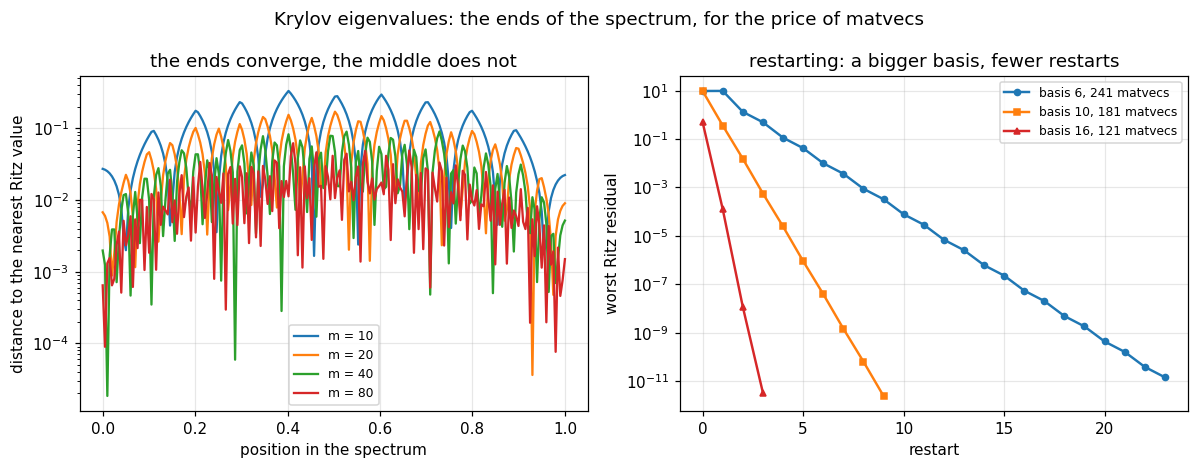

In [11]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: how well each eigenvalue is approximated, by position in the spectrum
op_p = ke.sparse_laplacian(200)
exact_p = ke.laplacian_eigenvalues(200)
for m_p, style in ((10, "C0-"), (20, "C1-"), (40, "C2-"), (80, "C3-")):
    c_p = ke.convergence_order(op_p, m_p, exact=exact_p, rng=np.random.default_rng(3))
    axL.semilogy(c_p["position"], np.maximum(c_p["distance"], 1e-17), style, lw=1.5,
                 label=f"m = {m_p}")
axL.set_xlabel("position in the spectrum")
axL.set_ylabel("distance to the nearest Ritz value")
axL.set_title("the ends converge, the middle does not")
axL.legend(fontsize=8)

# right: the free residual bound, restart by restart, at several basis sizes
op_h, _ = ke.operator_with_spectrum(np.arange(1.0, 31.0) ** 1.5, seed=3)
for basis, style in ((6, "C0o-"), (10, "C1s-"), (16, "C3^-")):
    r_h = ke.restarted_arnoldi(op_h, n_wanted=2, basis_size=basis, tol=1e-13,
                               max_restarts=120, rng=np.random.default_rng(7))
    axR.semilogy(np.maximum(r_h.history, 1e-17), style, lw=1.6, ms=4,
                 markevery=max(1, len(r_h.history) // 15),
                 label=f"basis {basis}, {r_h.matvecs} matvecs")
axR.set_xlabel("restart")
axR.set_ylabel("worst Ritz residual")
axR.set_title("restarting: a bigger basis, fewer restarts")
axR.legend(fontsize=8)

fig.suptitle("Krylov eigenvalues: the ends of the spectrum, for the price of matvecs",
             fontsize=12)
fig.tight_layout()
plt.show()

**The left panel is section 4.** Every curve dips at both ends and bulges in the middle, and
raising $m$ lowers the ends much faster than the middle.

---

## 10. Exercises

**Level 1, conceptual**

1.1 Lessons 37 and 38 both start by reducing the matrix. What exactly stops that at
$n = 10^6$, and what does a Krylov method do instead?

1.2 The Ritz residual is available without forming the Ritz vector. Why does that matter, given
that forming one costs a single matrix-vector product?

1.3 Lanczos without reorthogonalization returned an eigenvalue three times. Is the answer wrong,
and what should you do?

**Level 2, mathematical**

2.1 Prove that the Ritz residual is orthogonal to the subspace, and hence that the Ritz value is
the Rayleigh quotient of the Ritz vector.

2.2 Derive $\|A\mathbf{y}-\theta\mathbf{y}\| = |h_{m+1,m}||s_m|$ from the Arnoldi relation, and
say what changes for a non-symmetric $A$.

2.3 Prove the Cauchy interlacing that keeps the Ritz values inside the true spectrum.

2.4 State the Kaniel-Paige bound and show it reduces to lesson 24's conjugate gradient bound
when the relevant polynomial is the same.

2.5 State Paige's theorem on loss of orthogonality, and explain why it implies ghosts are a
symptom of convergence rather than of failure.

**Level 3, computational**

3.1 Implement **implicitly restarted Arnoldi** properly, applying the unwanted Ritz values as
shifts in $p$ QR steps rather than re-projecting. Compare against the thick restart here.

3.2 Implement **shift and invert** Lanczos with a sparse factorization, and use it to find
interior eigenvalues. Measure how the factorization cost compares with the matvecs saved.

3.3 Implement the **Cullum-Willoughby** ghost test: compare the spectrum of $T_m$ with that of
$T_m$ with its first row and column deleted, and discard the values appearing in both. Show it
recovers the true spectrum from a non-reorthogonalized run.

**Level 4, experimental**

4.1 Measure the number of matvecs against the relative gap of the wanted eigenvalue, and fit the
relationship. Compare with the Kaniel-Paige prediction.

4.2 Measure where orthogonality is lost against where the first Ritz value converges, and
confirm Paige's theorem quantitatively rather than qualitatively.

4.3 Measure the restart trade-off: matvecs against basis size, for several numbers of wanted
eigenvalues, and find the basis size minimising total work.

**Level 5, advanced**

5.1 **Non-symmetric Krylov eigenvalues.** Arnoldi handles them, and the Ritz values can be
complex and badly conditioned. Explain what changes, implement it, and relate the difficulty to
lesson 35's individual condition numbers.

5.2 **Block methods.** Starting from $p$ vectors rather than one finds $p$ eigenvalues at once
and handles multiplicity, which a single vector cannot. Implement block Lanczos and explain what
it can find that the unblocked version provably cannot.

5.3 **Why ARPACK stopped being the default.** Modern libraries increasingly use randomised or
contour integration methods for some problems. Identify what those do that Krylov methods do
not, and where the crossover is.

## 11. Key takeaways

- **Krylov methods need only matrix-vector products**, so they work where the $O(n^3)$
  reductions of lessons 37 and 38 cannot even begin.
- **Rayleigh-Ritz is lesson 36's Rayleigh quotient with a subspace in place of a vector**, and
  it has the same optimality: the residual is orthogonal to the subspace.
- **The Ritz values lie strictly inside the true spectrum** and approach the extremes from
  within, so they can never overshoot.
- **The stopping test is free.** $\|A\mathbf{y}-\theta\mathbf{y}\| = |h_{m+1,m}||s_m|$ exactly,
  measured ratio **1.0000** at every Ritz value, with no Ritz vector formed and no matvec spent.
- **The extremes converge first**, which is Kaniel-Paige and is lesson 24's Chebyshev bound
  again. Measured: the interior is **4 to 6 times worse** at every basis size.
- **And the obvious way to measure that is wrong.** One interior eigenvalue's distance to the
  nearest Ritz value rewards accidents; at $m = 5$ it scored the middle *better* than the
  extremes. Medians over bands of the whole spectrum do not.
- **Ghosts are duplicates of converged eigenvalues**, and by Paige's theorem they appear exactly
  when a Ritz value converges. Measured: turning the separation of the top eigenvalue from 1 to
  30 takes the orthogonality loss from $10^{-7}$ to 4.5 and the ghost count from 0 to 3.
- **The answers stay right.** The top eigenvalue was correct to $10^{-13}$ in every ghost-ridden
  run: Lanczos lies about multiplicities, not about values.
- **Restarting bounds the memory**, and a bigger basis buys fewer restarts at more work each.
- **A million by a million eigenvalue problem took one restart, 39 matvecs and two seconds**,
  against 8000 GB to store the matrix, and the matvec count did not grow with $n$ at all.
- **Because the cost is set by the spectrum, not by the size.** The plain Laplacian, whose top
  eigenvalues are separated by $3\times10^{-7}$ at $n = 10^4$, does not converge in 120
  restarts, while the same operator with one spiked entry converges in **one**.
- **So look at the gaps before choosing the method.** A Krylov eigensolver is for well separated
  extremes, and shift-and-invert is the fix for anything else, at the price of the factorization
  these methods exist to avoid.

## Where this goes next

**Lesson 40** handles $A\mathbf{x} = \lambda B\mathbf{x}$, the last of the eigenvalue variants,
and the QZ algorithm that solves it when $B$ is singular.

**Lesson 41** builds the SVD, and **lesson 42** computes it, where the Lanczos method of this
lesson reappears as **Golub-Kahan bidiagonalization** applied one vector at a time: the same
idea, applied to $A^TA$ without ever forming it.

**Lesson 43** uses the top few singular values that these methods deliver, in low rank
approximation, where wanting the extremes of a spectrum is the whole point.